In [ ]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Menentukan Parameter Simulasi

In [ ]:
# Parameter simulasi
NUM_AGENTS = 100
NUM_ITERATIONS = 1000
PRODUCT_PRICE = 50

# Skenario diskon
discount_rates = [0.0, 0.1, 0.3, 0.5]

Membuat Agent Pelanggan

In [ ]:
# Membuat data agent
agents = []

for i in range(NUM_AGENTS):
    agent = {
        "purchase_probability": random.uniform(0.1, 0.5),
        "interest_level": random.uniform(0.0, 1.0),
        "budget": random.uniform(50, 500)
    }

    agents.append(agent)

# Menampilkan 5 agent pertama
agents[:5]

[{'purchase_probability': 0.3402489652878852,
  'interest_level': 0.8318477481500015,
  'budget': 64.45680211968501},
 {'purchase_probability': 0.27078376205186894,
  'interest_level': 0.6780037366649145,
  'budget': 453.09062837670325},
 {'purchase_probability': 0.3372388833018085,
  'interest_level': 0.861193916282621,
  'budget': 230.95424367143235},
 {'purchase_probability': 0.29754792007312014,
  'interest_level': 0.11606061160740411,
  'budget': 132.479809703096},
 {'purchase_probability': 0.44105302796240586,
  'interest_level': 0.007779456790872219,
  'budget': 288.2446535021204}]

Fungsi Simulasi Pembelian

In [ ]:
def simulate_purchase(agent, discount):

    P = agent["purchase_probability"]
    I = agent["interest_level"]
    B = agent["budget"]

    # Menghitung probabilitas akhir
    P_final = P + (I * discount)

    # Membatasi probabilitas maksimal = 1
    P_final = min(P_final, 1)

    # Menghitung harga setelah diskon
    final_price = PRODUCT_PRICE * (1 - discount)

    # Cek budget pelanggan
    if B < final_price:
        return 0

    # Generate random value
    r = random.random()

    # Keputusan pembelian
    if r < P_final:
        return 1
    else:
        return 0

Menjalankan Simulasi

In [ ]:
results = {}

for discount in discount_rates:

    total_transactions = []

    for iteration in range(NUM_ITERATIONS):

        transactions = 0

        for agent in agents:

            buy = simulate_purchase(agent, discount)

            transactions += buy

        total_transactions.append(transactions)

    results[discount] = total_transactions

Menampilkan Hasil Simulasi

In [ ]:
for discount, transactions in results.items():

    average_transactions = np.mean(transactions)

    print(f"Discount {int(discount*100)}%")
    print(f"Rata-rata transaksi: {average_transactions:.2f}")
    print("-" * 40)

Discount 0%
Rata-rata transaksi: 29.94
----------------------------------------
Discount 10%
Rata-rata transaksi: 34.83
----------------------------------------
Discount 30%
Rata-rata transaksi: 44.91
----------------------------------------
Discount 50%
Rata-rata transaksi: 55.16
----------------------------------------


Visualisasi Hasil Simulasi

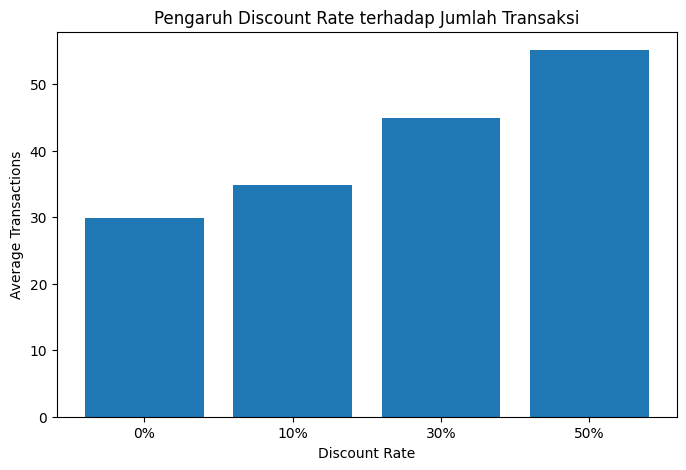

In [ ]:
average_results = []

discount_labels = []

for discount, transactions in results.items():

    avg = np.mean(transactions)

    average_results.append(avg)

    discount_labels.append(f"{int(discount*100)}%")

plt.figure(figsize=(8,5))

plt.bar(discount_labels, average_results)

plt.xlabel("Discount Rate")
plt.ylabel("Average Transactions")
plt.title("Pengaruh Discount Rate terhadap Jumlah Transaksi")

plt.show()

#MINGGU 8

Statistik Evaluasi Simulasi

In [ ]:
# Statistik evaluasi simulasi

for discount, transactions in results.items():

    print(f"Discount {int(discount*100)}%")

    print(f"Rata-rata transaksi : {np.mean(transactions):.2f}")
    print(f"Maksimum transaksi  : {np.max(transactions)}")
    print(f"Minimum transaksi   : {np.min(transactions)}")
    print(f"Standar deviasi     : {np.std(transactions):.2f}")

    print("-" * 50)

Discount 0%
Rata-rata transaksi : 29.94
Maksimum transaksi  : 46
Minimum transaksi   : 17
Standar deviasi     : 4.56
--------------------------------------------------
Discount 10%
Rata-rata transaksi : 34.83
Maksimum transaksi  : 49
Minimum transaksi   : 22
Standar deviasi     : 4.59
--------------------------------------------------
Discount 30%
Rata-rata transaksi : 44.91
Maksimum transaksi  : 59
Minimum transaksi   : 30
Standar deviasi     : 4.82
--------------------------------------------------
Discount 50%
Rata-rata transaksi : 55.16
Maksimum transaksi  : 72
Minimum transaksi   : 41
Standar deviasi     : 4.66
--------------------------------------------------


Visualisasi Evaluasi per Iterasi

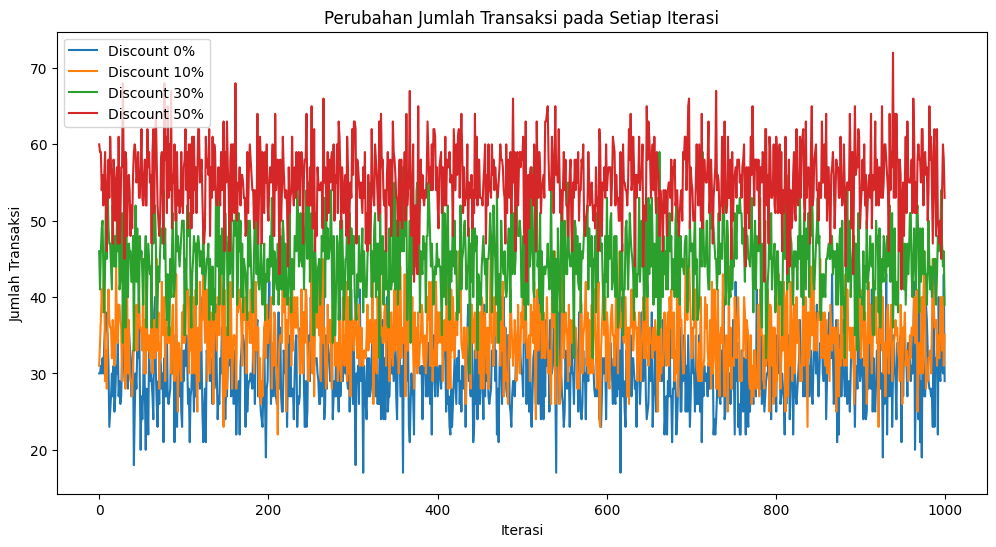

In [ ]:
plt.figure(figsize=(12,6))

for discount, transactions in results.items():

    plt.plot(
        transactions,
        label=f"Discount {int(discount*100)}%"
    )

plt.xlabel("Iterasi")
plt.ylabel("Jumlah Transaksi")
plt.title("Perubahan Jumlah Transaksi pada Setiap Iterasi")

plt.legend()

plt.show()

#MINGGU 10 — IMPLEMENTASI FITUR TAMBAHAN
Simulasi dengan fitur Shopping Mood

In [ ]:
# Menambahkan shopping mood ke agent lama

for agent in agents:

    agent["shopping_mood"] = random.uniform(0.0, 1.0)

# Menampilkan 5 agent pertama
agents[:5]

[{'purchase_probability': 0.3402489652878852,
  'interest_level': 0.8318477481500015,
  'budget': 64.45680211968501,
  'shopping_mood': 0.5485331953646728},
 {'purchase_probability': 0.27078376205186894,
  'interest_level': 0.6780037366649145,
  'budget': 453.09062837670325,
  'shopping_mood': 0.39603134595689904},
 {'purchase_probability': 0.3372388833018085,
  'interest_level': 0.861193916282621,
  'budget': 230.95424367143235,
  'shopping_mood': 0.10326224628447933},
 {'purchase_probability': 0.29754792007312014,
  'interest_level': 0.11606061160740411,
  'budget': 132.479809703096,
  'shopping_mood': 0.9004185984399149},
 {'purchase_probability': 0.44105302796240586,
  'interest_level': 0.007779456790872219,
  'budget': 288.2446535021204,
  'shopping_mood': 0.4598243740828428}]

Function Baru untuk Minggu 10

In [ ]:
def simulate_purchase_mood(agent, discount):

    P = agent["purchase_probability"]

    I = agent["interest_level"]

    B = agent["budget"]

    M = agent["shopping_mood"]

    # Rumus baru
    P_final = P + (I * discount) + (M * 0.2)

    # Maksimal probabilitas
    P_final = min(P_final, 1)

    # Harga setelah diskon
    final_price = PRODUCT_PRICE * (1 - discount)

    # Cek budget
    if B < final_price:
        return 0

    # Random value
    r = random.random()

    # Keputusan pembelian
    if r < P_final:
        return 1
    else:
        return 0

Menjalankan Simulasi Minggu 10

In [ ]:
mood_results = {}

for discount in discount_rates:

    total_transactions = []

    for iteration in range(NUM_ITERATIONS):

        transactions = 0

        for agent in agents:

            buy = simulate_purchase_mood(agent, discount)

            transactions += buy

        total_transactions.append(transactions)

    mood_results[discount] = total_transactions

Statistik Minggu 10

In [ ]:
for discount, transactions in mood_results.items():

    print(f"Discount {int(discount*100)}%")

    print(f"Rata-rata transaksi : {np.mean(transactions):.2f}")
    print(f"Maksimum transaksi  : {np.max(transactions)}")
    print(f"Minimum transaksi   : {np.min(transactions)}")
    print(f"Standar deviasi     : {np.std(transactions):.2f}")

    print("-" * 50)

Discount 0%
Rata-rata transaksi : 40.35
Maksimum transaksi  : 57
Minimum transaksi   : 21
Standar deviasi     : 4.65
--------------------------------------------------
Discount 10%
Rata-rata transaksi : 45.58
Maksimum transaksi  : 62
Minimum transaksi   : 31
Standar deviasi     : 4.89
--------------------------------------------------
Discount 30%
Rata-rata transaksi : 55.66
Maksimum transaksi  : 74
Minimum transaksi   : 41
Standar deviasi     : 4.79
--------------------------------------------------
Discount 50%
Rata-rata transaksi : 65.61
Maksimum transaksi  : 78
Minimum transaksi   : 52
Standar deviasi     : 4.39
--------------------------------------------------


Grafik Minggu 10

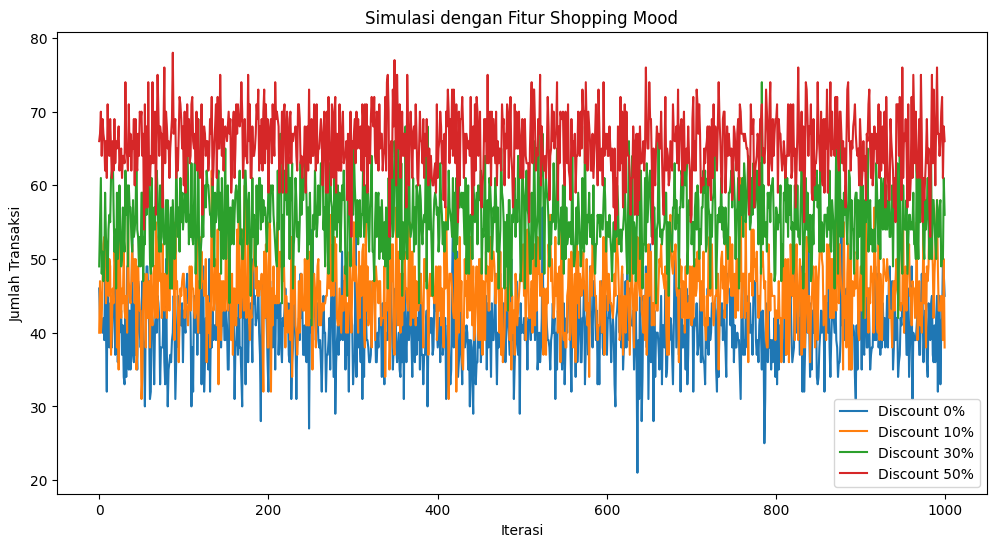

In [ ]:
plt.figure(figsize=(12,6))

for discount, transactions in mood_results.items():

    plt.plot(
        transactions,
        label=f"Discount {int(discount*100)}%"
    )

plt.xlabel("Iterasi")
plt.ylabel("Jumlah Transaksi")
plt.title("Simulasi dengan Fitur Shopping Mood")

plt.legend()

plt.show()

#MINGGU 12 — UJI SKENARIO (MONTE CARLO)

Function Membuat Scenario Agent

In [ ]:
def create_agents_with_mood_range(min_mood, max_mood):

    scenario_agents = []

    for i in range(NUM_AGENTS):

        agent = {

            "purchase_probability": random.uniform(0.1, 0.5),

            "interest_level": random.uniform(0.0, 1.0),

            "budget": random.uniform(50, 500),

            "shopping_mood": random.uniform(min_mood, max_mood)
        }

        scenario_agents.append(agent)

    return scenario_agents

Membuat Skenario

In [ ]:
scenarios = {

    "Normal Mood": create_agents_with_mood_range(0.0, 1.0),

    "Low Mood": create_agents_with_mood_range(0.0, 0.3),

    "High Mood": create_agents_with_mood_range(0.7, 1.0)
}

Jalankan Monte Carlo Simulation

In [ ]:
scenario_results = {}

for scenario_name, scenario_agents in scenarios.items():

    total_transactions = []

    for iteration in range(NUM_ITERATIONS):

        transactions = 0

        for agent in scenario_agents:

            buy = simulate_purchase_mood(agent, 0.3)

            transactions += buy

        total_transactions.append(transactions)

    scenario_results[scenario_name] = total_transactions

Kenapa Discount = 0.3?

Karena:

30% adalah titik tengah yang bagus,
tidak terlalu kecil,
tidak terlalu ekstrem,
cocok untuk eksperimen perilaku.

Statistik Hasil Monte Carlo

In [ ]:
for scenario, transactions in scenario_results.items():

    print(f"Scenario: {scenario}")

    print(f"Rata-rata transaksi : {np.mean(transactions):.2f}")

    print(f"Maksimum transaksi  : {np.max(transactions)}")

    print(f"Minimum transaksi   : {np.min(transactions)}")

    print(f"Standar deviasi     : {np.std(transactions):.2f}")

    print("-" * 50)

Scenario: Normal Mood
Rata-rata transaksi : 53.33
Maksimum transaksi  : 68
Minimum transaksi   : 39
Standar deviasi     : 4.88
--------------------------------------------------
Scenario: Low Mood
Rata-rata transaksi : 51.19
Maksimum transaksi  : 67
Minimum transaksi   : 33
Standar deviasi     : 4.92
--------------------------------------------------
Scenario: High Mood
Rata-rata transaksi : 61.17
Maksimum transaksi  : 75
Minimum transaksi   : 49
Standar deviasi     : 4.50
--------------------------------------------------


Visualisasi Monte Carlo

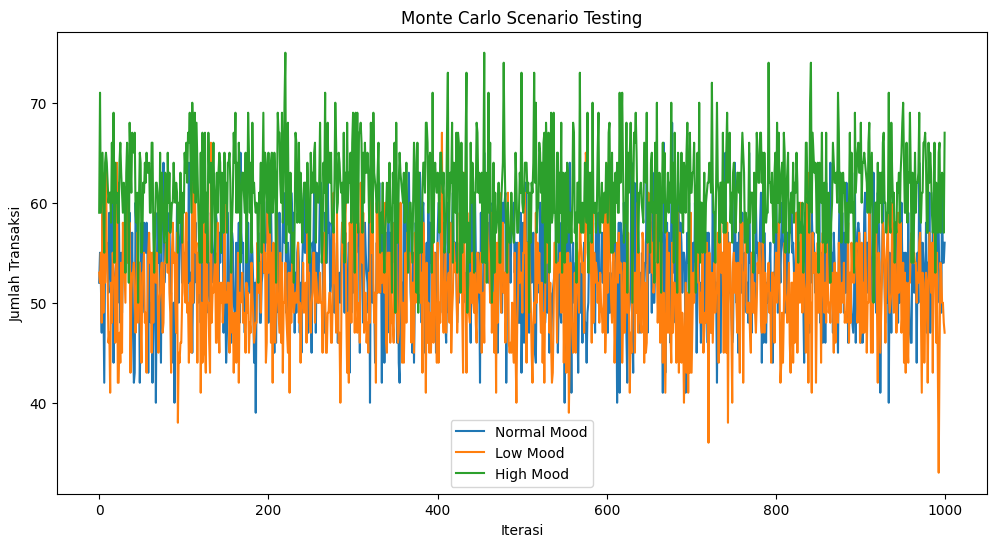

In [ ]:
plt.figure(figsize=(12,6))

for scenario, transactions in scenario_results.items():

    plt.plot(transactions, label=scenario)

plt.xlabel("Iterasi")

plt.ylabel("Jumlah Transaksi")

plt.title("Monte Carlo Scenario Testing")

plt.legend()

plt.show()